In [18]:
import pandas as pd

data = {
    "StudentID": [101,102,103,104,105,106,107,108,109,110,111,112],
    "Name": [
        "James Ade","Sarah B.",None,"John Doe","Chinedu Obi","James Ade",
        "Aisha Bello","Tunde Taiwo","Kelechi Okoro","Sarah B.","Jakes Tom","james Ade"
    ],
    "Gender": [
        "Male","Female","Male","Male","Male","Male",
        "Female","Male","Male","Female","Male","male"
    ],
    "MathScore": [85,92,None,78,88,95,60,70,-5,82,90,85],
    "ReadingScore": [80,90,85,78,None,95,60,70,75,82,90,85],
    "WritingScore": [78,92,88,None,87,95,60,70,75,82,90,None],
    "ParentalEducation": [
        "Bachelor","Master","High School","Bachelor","Master",None,
        "Associate","High School","Bachelor","Master","Bachelor","Bachelor"
    ],
    "Lunch": [
        "standard","free/reduced","standard","standard","free/reduced","standard",
        None,"standard","free/reduced","standard","standard","free/reduced"
    ]
}

df = pd.DataFrame(data)
df


,StudentID,Name,Gender,MathScore,ReadingScore,WritingScore,ParentalEducation,Lunch
0,101,James Ade,Male,85.0,80.0,78.0,Bachelor,standard
1,102,Sarah B.,Female,92.0,90.0,92.0,Master,free/reduced
2,103,None,Male,NaN,85.0,88.0,High School,standard
3,104,John Doe,Male,78.0,78.0,NaN,Bachelor,standard
4,105,Chinedu Obi,Male,88.0,NaN,87.0,Master,free/reduced
5,106,James Ade,Male,95.0,95.0,95.0,None,standard
6,107,Aisha Bello,Female,60.0,60.0,60.0,Associate,None
7,108,Tunde Taiwo,Male,70.0,70.0,70.0,High School,standard
8,109,Kelechi Okoro,Male,-5.0,75.0,75.0,Bachelor,free/reduced
9,110,Sarah B.,Female,82.0,82.0,82.0,Master,standard


In [19]:

print(df.info())
print(df.isnull().sum())


print(df.duplicated())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          12 non-null     int64  
 1   Name               11 non-null     object 
 2   Gender             12 non-null     object 
 3   MathScore          11 non-null     float64
 4   ReadingScore       11 non-null     float64
 5   WritingScore       10 non-null     float64
 6   ParentalEducation  11 non-null     object 
 7   Lunch              11 non-null     object 
dtypes: float64(3), int64(1), object(4)
memory usage: 900.0+ bytes
None
StudentID            0
Name                 1
Gender               0
MathScore            1
ReadingScore         1
WritingScore         2
ParentalEducation    1
Lunch                1
dtype: int64
0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
dtype

In [20]:

df['Gender'] = df['Gender'].str.capitalize()


df['Name'] = df['Name'].str.title()


df['Name'].fillna('Unknown', inplace=True)


df['ParentalEducation'].fillna('Unknown', inplace=True)


df['Lunch'].fillna('Standard', inplace=True)


C:\Users\JOHN\AppData\Local\Temp\ipykernel_10392\184226002.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Name'].fillna('Unknown', inplace=True)
C:\Users\JOHN\AppData\Local\Temp\ipykernel_10392\184226002.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, whe

In [21]:

for col in ['MathScore','ReadingScore','WritingScore']:
    df[col] = df[col].apply(lambda x: np.nan if (x is None or x < 0 or x > 100) else x)


for col in ['MathScore','ReadingScore','WritingScore']:
    df[col].fillna(df[col].mean(), inplace=True)


C:\Users\JOHN\AppData\Local\Temp\ipykernel_10392\3681609225.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [22]:
df.drop_duplicates(inplace=True)


In [23]:

df['TotalScore'] = df['MathScore'] + df['ReadingScore'] + df['WritingScore']


df['AverageScore'] = df['TotalScore'] / 3


In [24]:

print(df.groupby('Gender')[['MathScore','ReadingScore','WritingScore','TotalScore','AverageScore']].mean())


print(df['ParentalEducation'].value_counts())


print(df.sort_values('TotalScore', ascending=False)[['StudentID','Name','TotalScore']].head(3))


print(df['Lunch'].value_counts())


        MathScore  ReadingScore  WritingScore  TotalScore  AverageScore
Gender                                                                 
Female       78.0     77.333333     78.000000  233.333333     77.777778
Male         84.0     82.101010     82.933333  249.034343     83.011448
ParentalEducation
Bachelor       5
Master         3
High School    2
Unknown        1
Associate      1
Name: count, dtype: int64
    StudentID       Name  TotalScore
5         106  James Ade       285.0
1         102   Sarah B.       274.0
10        111  Jakes Tom       270.0
Lunch
standard        7
free/reduced    4
Standard        1
Name: count, dtype: int64


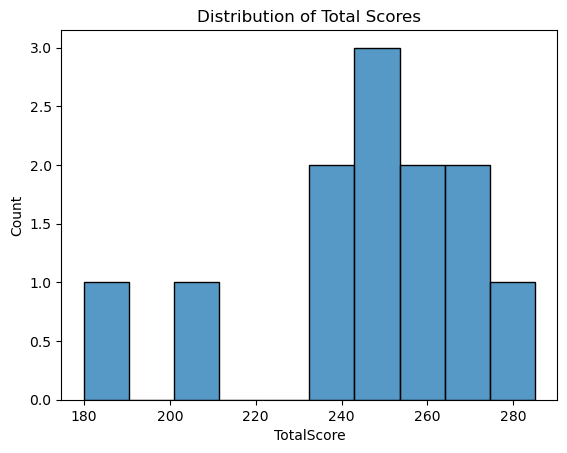

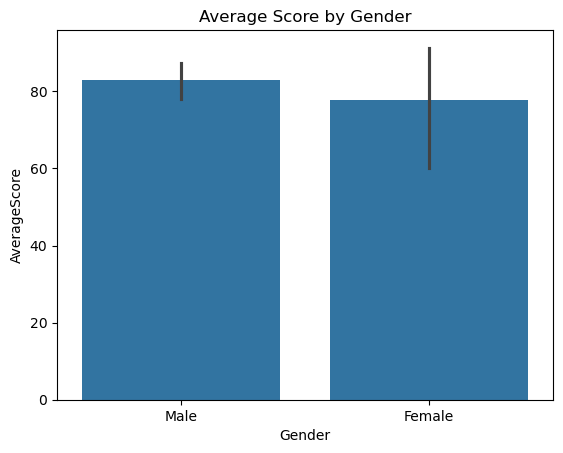

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(df['TotalScore'], bins=10)
plt.title('Distribution of Total Scores')
plt.show()


sns.barplot(x='Gender', y='AverageScore', data=df)
plt.title('Average Score by Gender')
plt.show()


In [2]:
import os
os.getcwd()


'C:\\Users\\JOHN'